# Molecular Representations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChemAI-Lab/AI4Chem/blob/main/website/modules/05-molecular_representations.ipynb)

In [2]:
# ! pip install py3dmol rdkit

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import py3Dmol
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, rdMolDescriptors, rdDistGeom, rdMolTransforms, QED
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole, SimilarityMaps
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import networkx as nx

IPythonConsole.ipython_useSVG = True
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300, 300

# Datasets

Number of molecules in Lipophilicity dataset: 4200


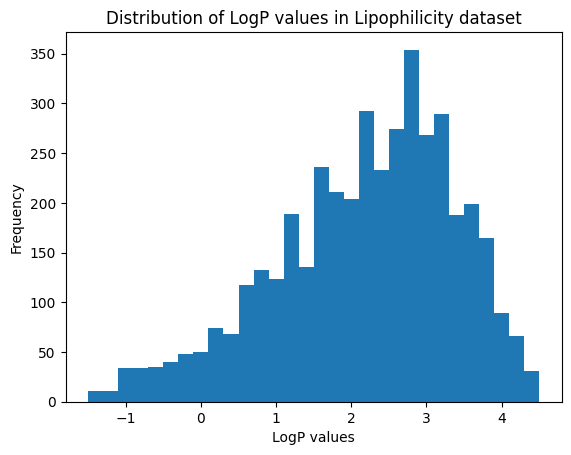

In [4]:
# load datasets
# Lipophilicity dataset
lipo_data_file = 'https://raw.githubusercontent.com/ChemAI-Lab/AI4Chem/main/website/modules/data/Lipophilicity.csv'
lipo_data = pd.read_csv(lipo_data_file)
lipo_data.head()

smiles_lipo = lipo_data['smiles'].tolist()
logp_values = np.array(lipo_data['exp'].tolist())
print(f'Number of molecules in Lipophilicity dataset: {len(smiles_lipo)}')

plt.hist(logp_values, bins=30)
plt.xlabel('LogP values')
plt.ylabel('Frequency')
plt.title('Distribution of LogP values in Lipophilicity dataset')
plt.show()


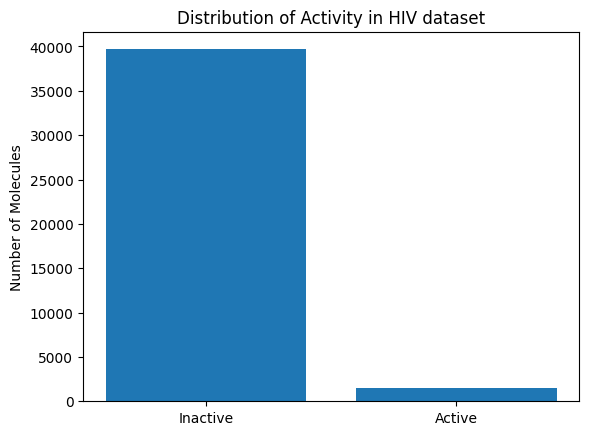

In [5]:
# HIV dataset
hiv_data_file = 'https://raw.githubusercontent.com/ChemAI-Lab/AI4Chem/main/website/modules/data/HIV.csv'
hiv_data = pd.read_csv(hiv_data_file)
hiv_data.head()

smiles_hiv = hiv_data['smiles'].tolist()
activity_values = np.array(hiv_data['HIV_active'].tolist())

plt.bar(['Inactive', 'Active'], [np.sum(activity_values == 0), np.sum(activity_values == 1)])
plt.ylabel('Number of Molecules')
plt.title('Distribution of Activity in HIV dataset')
plt.show()

# How can we represent molecules in a computer?

## Molecular descriptors

*Molecular descriptors capture diverse parts of the structural information of molecules and they are the support of many contemporary computer-assisted toxicological and chemical applications.*

Being able to numerically represent molecules aid with the prediction problem,
$$
y = f(\mathbf{{\cal M}})= f_\theta(\phi_\theta(\mathbf{{\cal M}})),
$$
where $\phi_\theta(\mathbf{{\cal M}})$ is the molecular descriptors used for supervised learning tasks like regression or classification.

<img src="https://raw.github.com/RodrigoAVargasHdz/CHEM-4PB3/master/Course_Notes/Figures/440801_1_En_1_Fig1_HTML.png"  width="500" height="700">

Figure from [link](https://link.springer.com/protocol/10.1007/978-1-4939-7899-1_1)


Molecular descriptors can describe different levels of information, from bulk properties to complex three-dimensional definitions or substructure frequency.
1. **0-Dimensional**:\
   atom counts (e.g., number of carbon atoms), molecular weight, and sum or average of atomic properties (e.g., atomic van der Waals volumes).
2. **1-Dimensional**:\
   molecules are perceived as a set of substructures, such as functional groups or atom-centered fragments.
3. **2-Dimensional**:\
   molecule is represented as a graph, whose vertexes are the atoms and edges are the bonds, and specific chemical properties of atoms are considered.
4. **3-Dimensional**:\
   descriptors deriving from 3D representation.
5. **4-Dimensional**:\
   molecular geometry combined with an “additional dimension/information”, e.g., representing each ligand by an ensemble of conformations, protonation states, and/or orientations.


### 0-Dimensional: Classical molecular descriptors and binary fingerprints ###


**Classical molecular descriptors** (MDs) are designed to encode a precise structural/chemical feature (or a set of features of different complexity) into one, single number. <br>
They can also be combined with other molecular properties that could be efficiently estimated. 

**RDKit molecular descriptors** ([list](https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html?highlight=calcnumhba#rdkit.Chem.rdMolDescriptors.CalcNumHBA))


In [6]:
def compute_classical_descriptors(smiles, descriptor_names=None):
    """
    Return (values_array, names_list) of RDKit classical descriptors for a SMILES string.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES: %s" % smiles)

    all_desc = Descriptors._descList  # list of (name, function)
    if descriptor_names is None:
        desc_list = all_desc
    else:
        wanted = set(descriptor_names)
        desc_list = [(n, f) for n, f in all_desc if n in wanted]

    names = [n for n, _ in desc_list]
    values = []
    for n, f in desc_list:
        try:
            values.append(float(f(mol)))
        except Exception:
            values.append(np.nan)

    return np.array(values, dtype=float), names


# Example usage with caffeine_smiles already defined in the notebook
caffeine_smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'

vec, desc_names = compute_classical_descriptors(caffeine_smiles)
print("Computed %d descriptors" % len(desc_names))
for n, v in zip(desc_names[:], vec[:]):  # show first 20
    print(n, f"{v:.2f}")

Computed 217 descriptors
MaxAbsEStateIndex 11.67
MaxEStateIndex 11.67
MinAbsEStateIndex 0.32
MinEStateIndex -0.36
qed 0.54
SPS 11.07
MolWt 194.19
HeavyAtomMolWt 184.11
ExactMolWt 194.08
NumValenceElectrons 74.00
NumRadicalElectrons 0.00
MaxPartialCharge 0.33
MinPartialCharge -0.33
MaxAbsPartialCharge 0.33
MinAbsPartialCharge 0.33
FpDensityMorgan1 1.14
FpDensityMorgan2 1.79
FpDensityMorgan3 2.43
BCUT2D_MWHI 16.16
BCUT2D_MWLOW 10.49
BCUT2D_CHGHI 2.11
BCUT2D_CHGLO -2.02
BCUT2D_LOGPHI 2.01
BCUT2D_LOGPLOW -2.37
BCUT2D_MRHI 5.69
BCUT2D_MRLOW 0.71
AvgIpc 2.54
BalabanJ 3.22
BertzCT 616.53
Chi0 10.46
Chi0n 8.18
Chi0v 8.18
Chi1 6.54
Chi1n 4.11
Chi1v 4.11
Chi2n 3.23
Chi2v 3.23
Chi3n 2.32
Chi3v 2.32
Chi4n 1.47
Chi4v 1.47
HallKierAlpha -1.85
Ipc 1876.09
Kappa1 8.74
Kappa2 2.57
Kappa3 0.88
LabuteASA 79.03
PEOE_VSA1 4.57
PEOE_VSA10 0.00
PEOE_VSA11 11.16
PEOE_VSA12 0.00
PEOE_VSA13 5.56
PEOE_VSA14 5.69
PEOE_VSA2 13.93
PEOE_VSA3 9.78
PEOE_VSA4 0.00
PEOE_VSA5 0.00
PEOE_VSA6 0.00
PEOE_VSA7 0.00
PEOE_VSA8 

In [7]:
import numpy as np
descriptor_values = []
for smi in smiles_lipo:
    vec, _ = compute_classical_descriptors(smi)
    descriptor_values.append(vec)

X_lipo = np.array(descriptor_values)
y_lipo = logp_values

# Check for NaNs in X_lipo before splitting
nan_mask = np.isnan(X_lipo)
n_nans = nan_mask.sum()
print("Total NaNs in X_lipo:", n_nans)

if n_nans > 0:
    # Which columns have NaNs and how many
    col_nan_counts = nan_mask.sum(axis=0)
    nan_cols = np.where(col_nan_counts > 0)[0]
    print("Columns with NaNs:", nan_cols)
    print("NaNs per column:", col_nan_counts[nan_cols])

col_keep_mask = ~np.isnan(X_lipo).any(axis=0)
dropped = np.where(~col_keep_mask)[0]
print(f'Dropping {len(dropped)} columns with NaNs')

X_lipo = X_lipo[:, col_keep_mask]
desc_names = [d for d, keep in zip(desc_names, col_keep_mask) if keep]


X_lipo_train, X_lipo_test, y_lipo_train, y_lipo_test = train_test_split(X_lipo, y_lipo, test_size=0.2, random_state=42)
print(f'Training set size: {X_lipo_train.shape[0]} molecules')
print(f'Test set size: {X_lipo_test.shape[0]} molecules')

Total NaNs in X_lipo: 12
Columns with NaNs: [11 12 13 14 18 19 20 21 22 23 24 25]
NaNs per column: [1 1 1 1 1 1 1 1 1 1 1 1]
Dropping 12 columns with NaNs
Training set size: 3360 molecules
Test set size: 840 molecules


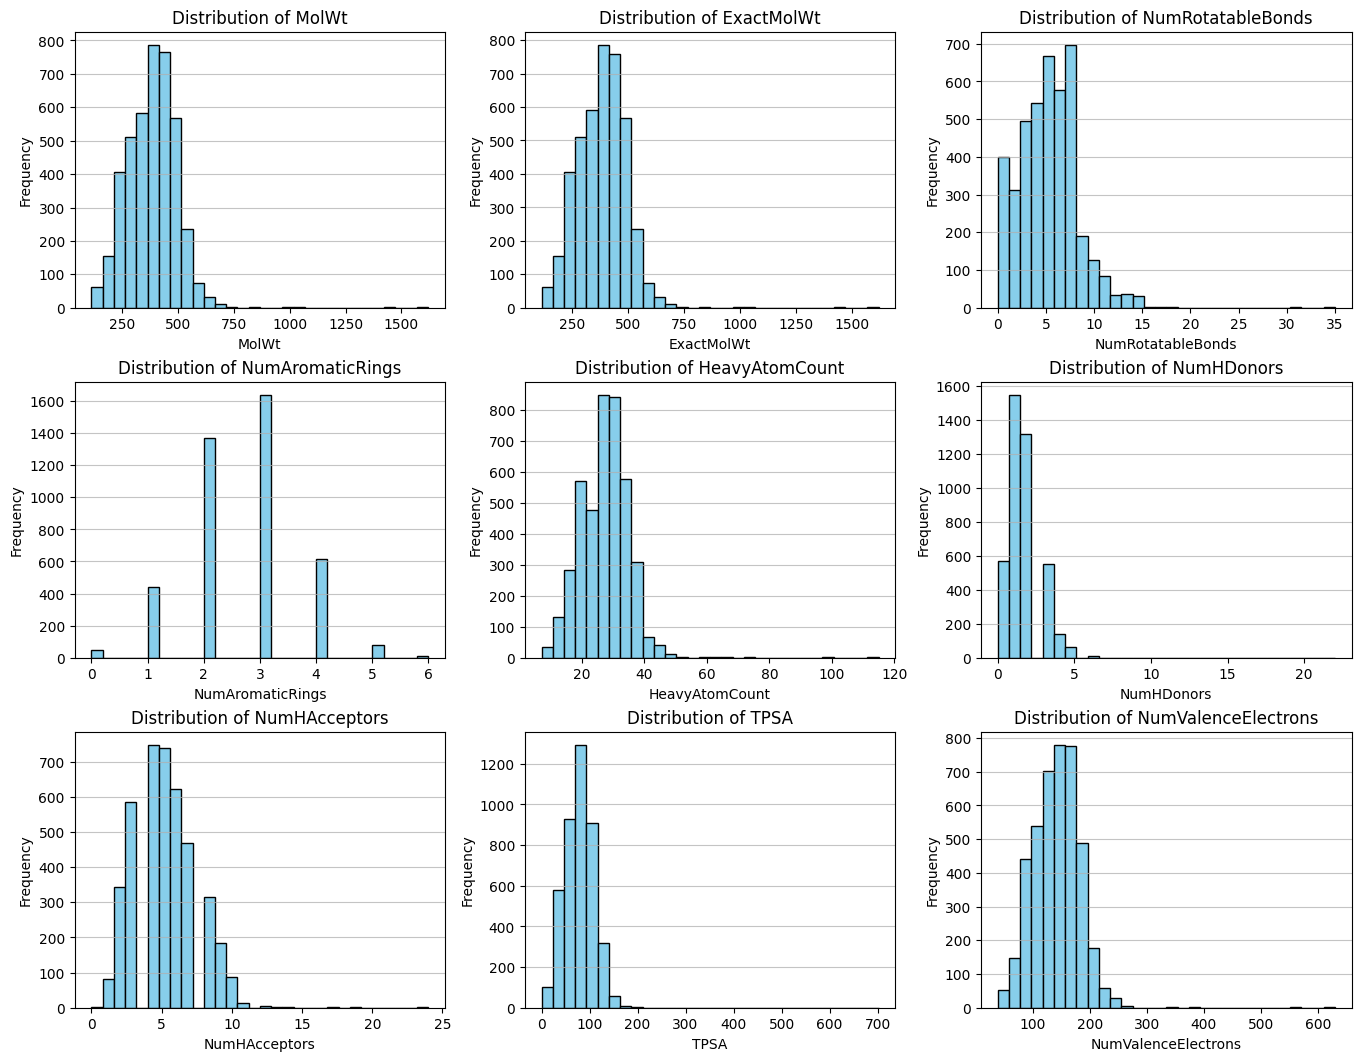

In [8]:
# Mosaic of histograms for descriptors (subset)
import math
import matplotlib.pyplot as plt

# Topological Polar Surface Area (TPSA)
desc_names_subset = ['MolWt', 'ExactMolWt', 'NumRotatableBonds',  'NumAromaticRings',
                     'HeavyAtomCount', 'NumHDonors', 'NumHAcceptors', 'TPSA', "NumValenceElectrons"]

n = len(desc_names_subset)
cols = 3  # adjust as needed
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.5), constrained_layout=True)
axes = axes.flatten() if n > 1 else [axes]

for i, desc_name in enumerate(desc_names_subset):
    ax = axes[i]
    idx = desc_names.index(desc_name)
    ax.hist(X_lipo[:, idx], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution of {desc_name}')
    ax.set_xlabel(desc_name)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.75)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.show()

In [9]:
# normalize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Doesn't affect the results
y_lipo_train_norm = scaler.fit_transform(y_lipo_train.reshape(-1, 1)).flatten()
y_lipo_test_norm = scaler.transform(y_lipo_test.reshape(-1, 1)).flatten()

# Without normalization linear model does not work well
X_lipo_train_norm = scaler.fit_transform(X_lipo_train)
X_lipo_test_norm = scaler.transform(X_lipo_test)

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

lr = LinearRegression(fit_intercept=True)
lr.fit(X_lipo_train_norm, y_lipo_train)
print("Linear model Coefficients:")
print(lr.coef_)

y_lipo_pred_train = lr.predict(X_lipo_train_norm)
mae_tr, r2_train = mean_absolute_error(y_lipo_train, y_lipo_pred_train), r2_score(y_lipo_train, y_lipo_pred_train)
y_lipo_pred_test = lr.predict(X_lipo_test_norm)
mae_test, r2_test = mean_absolute_error(y_lipo_test, y_lipo_pred_test), r2_score(y_lipo_test, y_lipo_pred_test)

print(f"Training MAE: {mae_tr:.3f}, R2: {r2_train:.3f}")
print(f"Test MAE: {mae_test:.3f}, R2: {r2_test:.3f}")


Linear model Coefficients:
[ 5.11269117e-02  5.11269119e-02  5.39909723e-02 -5.44013723e-03
  4.17334318e-02 -2.54802616e-02 -2.21212912e+02  1.99528209e+02
  4.98429141e+00  3.79959151e+01 -4.23174686e-10  3.42382297e-02
 -3.90557950e-01  3.57689650e-01  4.52924330e-02 -2.68409595e-01
  2.72607040e-02  5.41654333e+01 -1.43119701e+01 -1.23748741e+01
  1.55328664e+01  6.02073635e+00  7.17634692e-01  8.69663555e-01
  2.05019450e+00 -2.06579260e-01  4.52037086e-01  1.50848432e-01
 -2.85983528e-01 -7.31652340e-01  1.17814302e-01  5.88015898e-01
 -4.59376043e-01  2.45168152e-01  4.09052993e+02 -1.92585849e+01
 -1.86208947e+01 -1.51670881e+01 -1.18010009e+01 -1.03731521e+01
 -9.49447096e+00 -1.48704064e+01 -1.57590801e+01 -1.23612045e+01
 -1.01679007e+01 -4.43803760e+01 -4.55978280e+01 -3.62881932e+01
 -2.41494182e+01 -1.70156520e+01 -3.03083934e+01 -3.51636857e+00
 -1.64927063e+01 -1.09583824e+01 -4.20935848e+01 -3.64273008e+01
 -4.98929098e+01 -2.67967315e-11 -1.81924204e+01 -1.41888591e+0

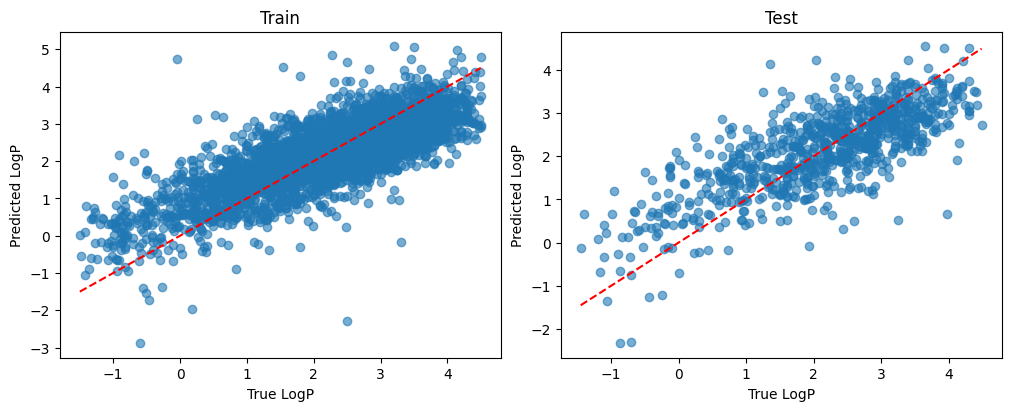

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Train panel
axes[0].scatter(y_lipo_train, y_lipo_pred_train, alpha=0.6)
axes[0].plot([min(y_lipo_train), max(y_lipo_train)], [
             min(y_lipo_train), max(y_lipo_train)], color='red', linestyle='--')
axes[0].text(0.05, 0.9, f'MAE: {mae_tr:.3f}\nR2: {r2_train:.3f}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
axes[0].set_xlabel('True LogP')
axes[0].set_ylabel('Predicted LogP')
axes[0].set_title('Train')

# Test panel
axes[1].scatter(y_lipo_test, y_lipo_pred_test, alpha=0.6)
axes[1].plot([min(y_lipo_test), max(y_lipo_test)], [
             min(y_lipo_test), max(y_lipo_test)], color='red', linestyle='--')
axes[1].text(0.05, 0.9, f'MAE: {mae_test:.3f}\nR2: {r2_test:.3f}',
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
axes[1].set_xlabel('True LogP')
axes[1].set_ylabel('Predicted LogP')
axes[1].set_title('Test')

plt.show()

In [ ]:
# Neural Network Regression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


def get_device():
    """
    Automatically selects the best available device (CUDA, MPS, or CPU).
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

class SimpleNNS(nn.Module):
    def __init__(self, input_size=2, hidden_size=2, output_size=1, n_layers=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(input_size, hidden_size), activation()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), activation()]
        layers.append(nn.Linear(hidden_size, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
# Prepare data for PyTorch
X_lipo_train_tensor = torch.tensor(X_lipo_train_norm, dtype=torch.float32)
y_lipo_train_tensor = torch.tensor(y_lipo_train.reshape(-1, 1), dtype=torch.float32)
X_lipo_test_tensor = torch.tensor(X_lipo_test_norm, dtype=torch.float32)
y_lipo_test_tensor = torch.tensor(y_lipo_test.reshape(-1, 1), dtype=torch.float32)

n_epochs = 1000
batch_size = 32
learning_rate = 0.001
train_dataset = TensorDataset(X_lipo_train_tensor, y_lipo_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
model = SimpleNNS(input_size=X_lipo_train.shape[1], 
                  hidden_size=512, output_size=1,
                  n_layers=3, activation=nn.LeakyReLU).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    epoch_loss /= len(train_loader.dataset)
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {epoch_loss:.4f}')

Using device: mps
Epoch [100/1000], Loss: 0.0192
Epoch [200/1000], Loss: 0.0114
Epoch [300/1000], Loss: 0.0110
Epoch [400/1000], Loss: 0.0033


In [ ]:
assert 0

assert 0

In [ ]:
# one-hot-encoding
# ALPHABET: define SMILES characters

max_len = 30
SMILES_CHARS = ["7", "6", "o", "]", "3", "s", "(", "-", "S", "/", "B", "4", "[", ")", "#", "I",
                "l", "O", "H", "c", "1", "@", "=", "n", "P", "8", "C", "2", "F", "5", "r", "N", "+", "\\", " "]
# index
smi2index = dict((c, i) for i, c in enumerate(SMILES_CHARS))


def smiles_to_one_hot(smiles, maxlen=max_len):
    X = np.zeros((maxlen, len(SMILES_CHARS)))  # (maxlen, dictionary)
    # print(smiles,type(smiles))
    smiles = smiles.replace('\n', '')
    for i, c in enumerate(smiles):
        X[i, smi2index[c]] = 1
    return X


# caffeine one hot
caffeine_smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'
print(caffeine_smiles.split())

caffeine_one_hot = smiles_to_one_hot(caffeine_smiles)

print(caffeine_one_hot.shape)  # (120, 56)


plt.figure(figsize=(10, 10))
plt.imshow(caffeine_one_hot.T, cmap='binary')
# plt.xlabel('Tokens')
# plt.ylabel('SMILES')


caffeine_smiles_pad = caffeine_smiles + " " * (max_len - len(caffeine_smiles))

plt.title('One-hot encoding for %s' % caffeine_smiles)
plt.xticks(np.arange(len(list(caffeine_smiles))),
           list(caffeine_smiles), fontsize=8)
plt.yticks(np.arange(len(list(SMILES_CHARS))),
           list(SMILES_CHARS), fontsize=8)


# Regression Models

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression(fit_intercept=True)
lr.fit(X, y)

In [ ]:
# Linear regression via SVD (optionally compare with scikit-learn)
import numpy as np

# X: (n_samples, n_features), y: (n_samples,)
# Replace these with your feature matrix/targets
# X = ...
# y = ...

# Centering improves numerical stability
X_mean = X.mean(axis=0)
y_mean = y.mean()
Xc = X - X_mean
yc = y - y_mean

# SVD-based solution to least squares: w = V @ diag(1/s) @ U^T @ y
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
w = (Vt.T * (1.0 / s)) @ (U.T @ yc)
b = y_mean - X_mean @ w

# Predictions
y_pred = X @ w + b

# Optional: compare to scikit-learn
try:
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression(fit_intercept=True)
    lr.fit(X, y)
    print('SVD vs sklearn (w diff):', np.linalg.norm(w - lr.coef_))
    print('SVD vs sklearn (b diff):', abs(b - lr.intercept_))
except Exception as e:
    print('scikit-learn not available:', e)


In [ ]:
# Drop descriptor columns with any NaNs (keep all rows)
import numpy as np

col_keep_mask = ~np.isnan(X_lipo).any(axis=0)
dropped = np.where(~col_keep_mask)[0]
print(f'Dropping {len(dropped)} columns with NaNs')

X_lipo = X_lipo[:, col_keep_mask]
desc_names = [d for d, keep in zip(desc_names, col_keep_mask) if keep]

# If you already created desc_names_subset earlier, update it too
try:
    desc_names_subset = [d for d in desc_names_subset if d in desc_names]
except Exception:
    pass
